# Coresearcher (OpenAI powered)

This demo shows how to use an AstroFlow-aware coresearcher to help code data projects.


In [1]:
from research_assistant import (
    MemoryStore,
    ResearchAssistant,
    Retriever,
    build_messages,
    load_openai_api_key_from_shell_file,
    start_new_memory,
)


Set up the research assistant. 

In [ ]:
load_openai_api_key_from_shell_file("openai_key.txt")

model = "gpt-5.6"
memory_dir = 'memory'
ra = ResearchAssistant(model=model, memory_dir=memory_dir)


Ask your first question!

In [3]:
ra.ask("What's a random idea for a figure from Gaia DR3 data that I could make in Python using PySpark?")

### Idea: a velocity-stratified Gaia color–magnitude diagram

Plot the Gaia HR diagram in three tangential-velocity bins. The thin disk, thick disk, and halo sequences should change visibly between panels.

```python
from astroflow_spark_gaia import spark
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# Increase/decrease the RAND fraction depending on available resources.
df = spark.sql("""
SELECT
    bp_rp,
    phot_g_mean_mag + 5 * LOG10(parallax) - 10 AS M_G,
    4.74047 * SQRT(pmra * pmra + pmdec * pmdec) / parallax AS vtan
FROM gaiadr3.gaia_source
WHERE parallax > 0
  AND parallax_over_error > 10
  AND ruwe < 1.4
  AND phot_g_mean_mag IS NOT NULL
  AND bp_rp IS NOT NULL
  AND pmra IS NOT NULL
  AND pmdec IS NOT NULL
  AND bp_rp BETWEEN -0.5 AND 4.5
  AND RAND(42) < 0.002
""")

pdf = df.toPandas()

# Remove residual outliers.
pdf = pdf[
    np.isfinite(pdf["M_G"])
    & np.isfinite(pdf["vtan"])
    & pdf["M_G"].between(-5, 16)
    & pdf["v

'### Idea: a velocity-stratified Gaia color–magnitude diagram\n\nPlot the Gaia HR diagram in three tangential-velocity bins. The thin disk, thick disk, and halo sequences should change visibly between panels.\n\n```python\nfrom astroflow_spark_gaia import spark\nimport numpy as np\nimport matplotlib.pyplot as plt\nfrom matplotlib.colors import LogNorm\n\n# Increase/decrease the RAND fraction depending on available resources.\ndf = spark.sql("""\nSELECT\n    bp_rp,\n    phot_g_mean_mag + 5 * LOG10(parallax) - 10 AS M_G,\n    4.74047 * SQRT(pmra * pmra + pmdec * pmdec) / parallax AS vtan\nFROM gaiadr3.gaia_source\nWHERE parallax > 0\n  AND parallax_over_error > 10\n  AND ruwe < 1.4\n  AND phot_g_mean_mag IS NOT NULL\n  AND bp_rp IS NOT NULL\n  AND pmra IS NOT NULL\n  AND pmdec IS NOT NULL\n  AND bp_rp BETWEEN -0.5 AND 4.5\n  AND RAND(42) < 0.002\n""")\n\npdf = df.toPandas()\n\n# Remove residual outliers.\npdf = pdf[\n    np.isfinite(pdf["M_G"])\n    & np.isfinite(pdf["vtan"])\n    & pdf[

Now copy-paste that output into the next cell -- no modifications necessary -- and run:

Beginning the initilization of a spark cluster with 10 pods, 5 cores/pod and 7g mem/pod


26/08/17 08:51:36 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/08/17 08:51:36 WARN SparkConf: Note that spark.local.dir will be overridden by the value set by the cluster manager (via SPARK_LOCAL_DIRS in mesos/standalone/kubernetes and LOCAL_DIRS in YARN).
26/08/17 08:51:36 WARN Utils: Service 'sparkDriver' could not bind on port 41730. Attempting port 41731.
26/08/17 08:51:37 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/08/17 08:51:38 WARN Utils: Service 'org.apache.spark.network.netty.NettyBlockTransferService' could not bind on port 51730. Attempting port 51731.


Completed initialisation
Setting up SparkSQL
Setting up dataset Gaia DR3 with 4 databases gaiadr3, gaiadr3ssd, gaiaedr3ssd, gaiaedr3
Read default database gaiadr3ssd from environment config
A spark cluster has been sucessfully set up, you can interact with it via the "spark" object


/tmp/ipykernel_3385/1002187404.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


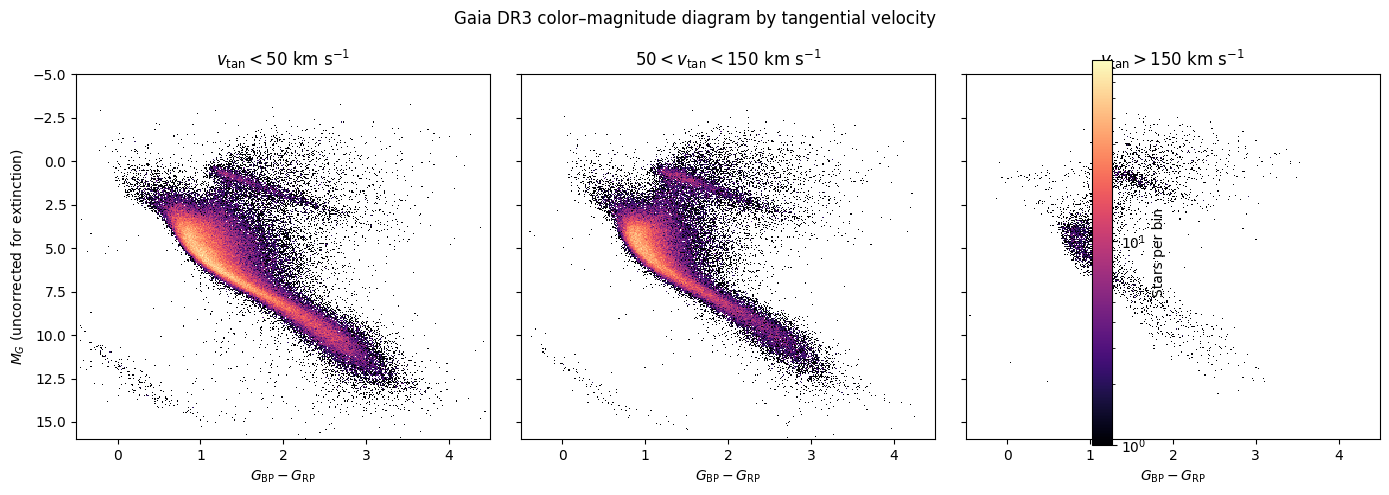

In [4]:
from astroflow_spark_gaia import spark
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# Increase/decrease the RAND fraction depending on available resources.
df = spark.sql("""
SELECT
    bp_rp,
    phot_g_mean_mag + 5 * LOG10(parallax) - 10 AS M_G,
    4.74047 * SQRT(pmra * pmra + pmdec * pmdec) / parallax AS vtan
FROM gaiadr3.gaia_source
WHERE parallax > 0
  AND parallax_over_error > 10
  AND ruwe < 1.4
  AND phot_g_mean_mag IS NOT NULL
  AND bp_rp IS NOT NULL
  AND pmra IS NOT NULL
  AND pmdec IS NOT NULL
  AND bp_rp BETWEEN -0.5 AND 4.5
  AND RAND(42) < 0.002
""")

pdf = df.toPandas()

# Remove residual outliers.
pdf = pdf[
    np.isfinite(pdf["M_G"])
    & np.isfinite(pdf["vtan"])
    & pdf["M_G"].between(-5, 16)
    & pdf["vtan"].between(0, 600)
]

velocity_bins = [
    (0, 50, r"$v_\mathrm{tan}<50$ km s$^{-1}$"),
    (50, 150, r"$50<v_\mathrm{tan}<150$ km s$^{-1}$"),
    (150, 600, r"$v_\mathrm{tan}>150$ km s$^{-1}$"),
]

xedges = np.linspace(-0.5, 4.5, 350)
yedges = np.linspace(-5, 16, 350)

histograms = []
for lo, hi, _ in velocity_bins:
    p = pdf[pdf["vtan"].between(lo, hi, inclusive="left")]
    H, _, _ = np.histogram2d(p["bp_rp"], p["M_G"], bins=(xedges, yedges))
    histograms.append(H)

vmax = max(H.max() for H in histograms)

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharex=True, sharey=True)

for ax, H, (_, _, title) in zip(axes, histograms, velocity_bins):
    mesh = ax.pcolormesh(
        xedges, yedges, H.T,
        cmap="magma",
        norm=LogNorm(vmin=1, vmax=vmax),
        shading="auto",
    )
    ax.set_title(title)
    ax.set_xlabel(r"$G_\mathrm{BP}-G_\mathrm{RP}$")
    ax.invert_yaxis()

axes[0].set_ylabel(r"$M_G$ (uncorrected for extinction)")
fig.colorbar(mesh, ax=axes, label="Stars per bin", pad=0.02)
fig.suptitle("Gaia DR3 color–magnitude diagram by tangential velocity")
plt.tight_layout()
plt.show()

The assistant is aware of questions you have asked before. So if the software doesn't work, you can input the error and receive corrections.

A previous output example:

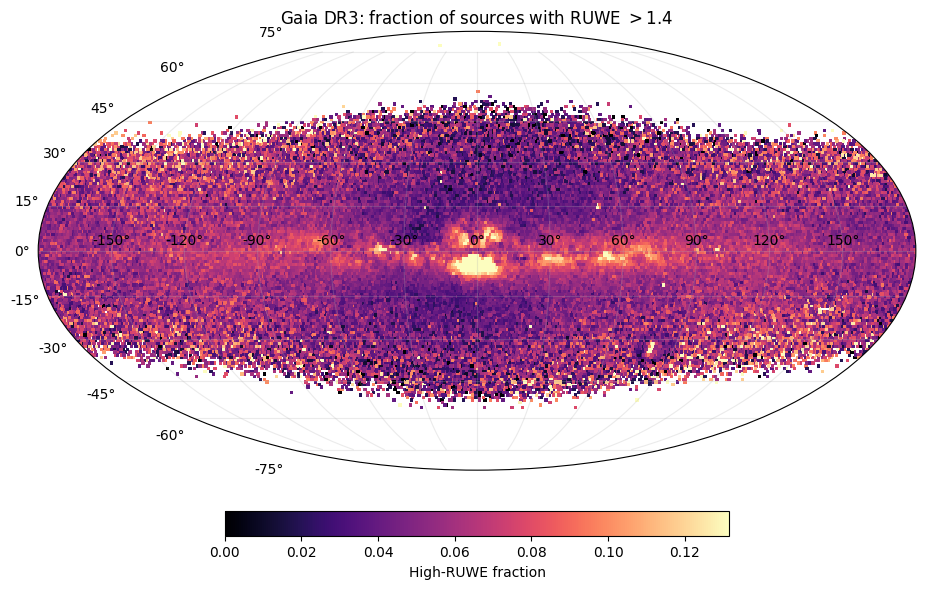

In [5]:
# A fun diagnostic: **an all-sky map of the fraction of stars with RUWE > 1.4**. It should reveal crowding, Gaia’s scanning/astrometric systematics, and regions rich in unresolved binaries.

from astroflow_spark_gaia import spark
import numpy as np
import matplotlib.pyplot as plt

q = """
SELECT
    FLOOR(l) AS lbin,
    FLOOR(b) AS bbin,
    COUNT(*) AS n,
    AVG(CASE WHEN ruwe > 1.4 THEN 1.0 ELSE 0.0 END) AS bad_ruwe_fraction
FROM gaiadr3.gaia_source
WHERE
    l IS NOT NULL
    AND b IS NOT NULL
    AND ruwe IS NOT NULL
    AND phot_g_mean_mag BETWEEN 12 AND 18
    AND visibility_periods_used >= 9
    AND rand(42) < 0.05
GROUP BY FLOOR(l), FLOOR(b)
HAVING COUNT(*) >= 50
"""

df = spark.sql(q).toPandas()


# Galactic longitude wrapped to [-180, 180], increasing to the left.
l = df["lbin"].to_numpy(dtype=np.float64) + 0.5
b = df["bbin"].to_numpy(dtype=np.float64) + 0.5
f = df["bad_ruwe_fraction"].to_numpy(dtype=np.float64)

l_plot = -(((l + 180.0) % 360.0) - 180.0)

f = df["bad_ruwe_fraction"].astype("float64").to_numpy()

fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection="mollweide")

im = ax.scatter(
    np.deg2rad(l_plot),
    np.deg2rad(b),
    c=f,
    s=6,
    marker="s",
    cmap="magma",
    vmin=0,
    vmax=np.nanpercentile(f, 99.),
    linewidths=0,
    rasterized=True,
)

ax.grid(alpha=0.25)
ax.set_title(r"Gaia DR3: fraction of sources with RUWE $>1.4$")
cb = fig.colorbar(im, ax=ax, orientation="horizontal", pad=0.08, fraction=0.05)
cb.set_label("High-RUWE fraction")

plt.tight_layout()
plt.show()

# A fun diagnostic: **an all-sky map of the fraction of stars with RUWE > 1.4**. It should reveal crowding, Gaia’s scanning/astrometric systematics, and regions rich in unresolved binaries.


The conversation log is in the memory directory you set above.